# Logistic Regression (Loan Approval Prediction) Assignment

In [1]:
# Q1. Data Loading & Understanding

# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# a) Load the dataset in Python.

# Load Dataset

df = pd.read_csv('/content/loan_approval - loan_approval.csv')

In [3]:
# b) Display the first 5 rows.

# Display First 5 rows

df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


In [4]:
# c) Check the shape of the dataset.

# Check Shape

df.shape

(2000, 8)

## Interpretation:

- Shows number of rows and columns in dataset.

In [5]:
# d) Display the data types of each column.

# Check Data Types

df.dtypes

,0
name,object
city,object
income,int64
credit_score,int64
loan_amount,int64
years_employed,int64
points,int64
loan_approved,bool


## Interpretation

- Helps identify numerical and categorical columns.

In [6]:
# Q2. Data Cleaning

# a) Check for missing values in the dataset.

df.isnull().sum()

,0
name,0
city,0
income,0
credit_score,0
loan_amount,0
years_employed,0
points,0
loan_approved,0


In [7]:
# b) Handle missing values appropriately.

# Numerical Columns

num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [8]:
# Categorical Columns

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [9]:
# Verify

df.isnull().sum()

,0
name,0
city,0
income,0
credit_score,0
loan_amount,0
years_employed,0
points,0
loan_approved,0


## Interpretation:

- Median used for numerical variables.
- Mode is used for categorical variables.

In [10]:
# c) Identify categorical columns present in the dataset.

df.select_dtypes(include='object').columns

Index(['name', 'city'], dtype='object')

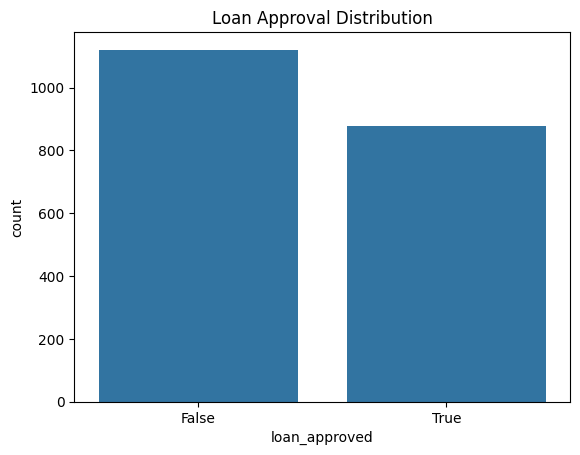

In [11]:
# Q3. Exploratory Data Analysis (EDA)

# a) Plot the distribution of the target variable.

# Suppose target column is loan_approved

sns.countplot(x='loan_approved', data=df)
plt.title("Loan Approval Distribution")
plt.show()

## Interpretation:

- If Approved > Rejected, dataset is slightly imbalanced.
- Majority class represents approved loans.

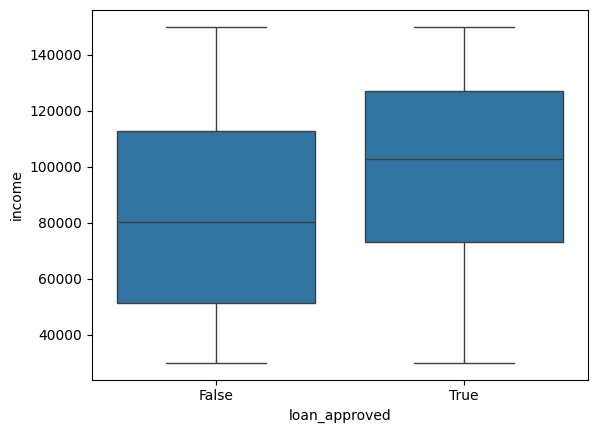

In [12]:
# b) Analyze the relationship between one numerical feature and the target variable.

# Example: Income

sns.boxplot(x='loan_approved',
            y='income',
            data=df)
plt.show()

## Interpretation:

- Compare income distribution between approved and rejected applicants.


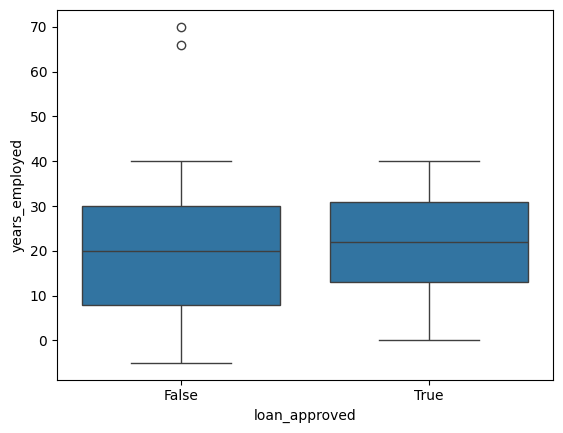

In [13]:
# c) Analyze the relationship between Years of Employment and the target variable.

# Years of Employment vs Target

sns.boxplot(x='loan_approved',
            y='years_employed',
            data=df)
plt.show()

## Interpretation:

- Higher employment years may indicate better approval chances.

In [14]:
# Q4. Outlier Detection and Treatment

# a) Detect outliers in numerical columns using the IQR method.

# Detect Outliers Using IQR

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) |
                  (df[col] > upper)]

    print(col, len(outliers))

income 0
credit_score 3
loan_amount 0
years_employed 2
points 0


In [15]:
# b) Treat outliers using capping techniques

# Treat Outliers Using Capping

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df[col] = np.where(df[col] < lower,
                       lower,
                       df[col])

    df[col] = np.where(df[col] > upper,
                       upper,
                       df[col])

## Interpretation

- Extreme values are capped.
- Data distribution becomes more stable.

In [16]:
# Q5. Convert target variables into numerical format suitable for model building and drop unnecessary columns.

# Convert Target Variable

df['loan_approved'] = df['loan_approved'].astype(int)

In [17]:
# Encode Remaining Categorical Variables

df = pd.get_dummies(df,
                    drop_first=True)

In [18]:
# Q6. Feature Selection and Data Splitting

# a) Separate independent variables (X) and dependent variable (y).

X = df.drop('loan_approved', axis=1)

y = df['loan_approved']

In [19]:
# b) Split the dataset into training and testing sets.

# Split Dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Interpretation

- 80% Training Data
- 20% Testing Data

In [20]:
# Q7. Apply feature scaling to the dataset using StandardScaler.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

## Interpretation:

- Features are standardized.
- Mean = 0
- Standard Deviation = 1

In [22]:
# Q8. Logistic Regression Model Building

# a) Train a Logistic Regression model.

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)


LogisticRegression()

In [23]:
# b) Predict the output for test data.

y_pred = model.predict(X_test)

y_pred

array([0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,

In [24]:
# Q9. Model Evaluation - Confusion Matrix

# a) Generate the confusion matrix.

# Generate Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,
                      y_pred)

print(cm)

[[214   3]
 [ 39 144]]


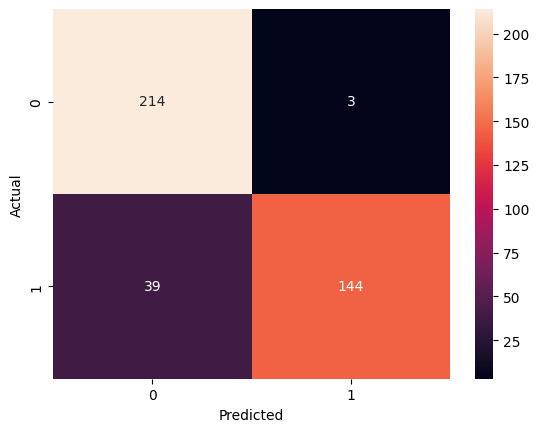

In [25]:
# Heatmap

sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## b) Interpret the results

### Interpretation

- TN = 214
- FP = 3
- FN = 39
- TP = 144

Meaning:

- 144 approved loans predicted correctly.
- 214 rejected loans predicted correctly
- 3 false approvals.
- 39 false rejections.



In [26]:
# Q10. Model Evaluation - ROC Curve & AUC

# a) Plot the ROC curve.

# Probability Prediction

y_prob = model.predict_proba(X_test)[:,1]

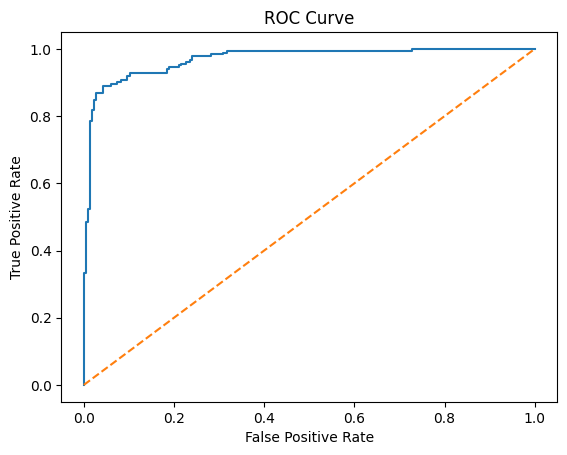

In [27]:
# ROC Curve

from sklearn.metrics import roc_curve

fpr, tpr, threshold = roc_curve(
    y_test,
    y_prob
)

plt.plot(fpr, tpr)

plt.plot([0,1],
         [0,1],
         linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

In [28]:
# b) Calculate the AUC score.

from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test,
    y_prob
)

print("AUC Score:", auc)

AUC Score: 0.9697564906449094


## Interpretation

- AUC = 0.50 -> Poor Model
- AUC = 0.70 - 0.80 -> Good Model
- AUC = 0.80 - 0.90 -> Very Good Model
- AUC > 0.90 -> Excellent Model